In [1]:
import sys
import os
import pandas as pd

# Add the parent directory (simcode) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.helper_functions.analyse_functions import aggregate_results
import re
from src.helper_functions.plot_functions import (
    plot_grid,
    plot_with_bands,
    plot_heatmap,
    plot_scatter_markers,
)
import ast
import numpy as np
from functools import partial
import re

In [2]:
import matplotlib.pyplot as plt


rcparams = {
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 9,
    "figure.titlesize": 11,
    "legend.fontsize": 10,
    "legend.title_fontsize": 10.5,
    "lines.linewidth": 1,
    "axes.linewidth": 0.5,
    "axes.facecolor": "white",
    "axes.grid": False,
    "lines.markersize": 3,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
}

plt.rcParams.update(rcparams)

In [3]:
linestyles = {
    "RV": "-",
    "DC": "--",
    "QAP": "-.",
    "CVM": ":",
}

colors = {
    "DC": "#0072B2",                  # Blue
    "AC_1": "#009E73",                # Bluish green
    "AC_sqrt": "#CC79A7",             # Reddish purple
    "AC_adaptive": "#6F3C8E",         # Dark purple
    "RVTest_permutation": "#D55E00",  # Vermilion
    "RVTest_asymptotic": "#E6AB02",   # Dark yellow
}

marker_map = {"DC": "x", "CCA": "o", "AC_1": "D", "AC_sqrt": "D", "AC_adaptive": "D", 
              "RVTest_permutation": "v", "RVTest_asymptotic": "v"}

In [4]:
def parse_result_string(s):
    # remove numpy scalar wrappers
    s_clean = re.sub(r"np\.float64\((.*?)\)", r"\1", s)

    return ast.literal_eval(s_clean)

In [5]:
results1 = pd.read_csv("simulation_results_20260730_0858.csv")
results2 = pd.read_csv("simulation_results_20260730_0928.csv")

In [6]:
results_concat = pd.concat([results1, results2])

In [7]:
from results.results_processing import process_results

results_all = process_results(results_concat)

/Users/lrcosta/umich/testing-network-independence/results/results_processing.py:628: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NA' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  result.loc[missing, column] = NA_VALUE


### Defining different aggregations

In [8]:
# based on dgp
results_gaussian = results_all[(results_all["dgp_name"] == "GaussianNetwork")].copy()
results_bernoulli = results_all[(results_all["dgp_name"] == "BernoulliNetwork")].copy()

In [11]:

# based on rho + dgp
results_null_gaussian = results_gaussian[(results_gaussian["rho"] == 0.0)].copy()
results_alt_gaussian = results_gaussian[(results_gaussian["rho"] != 0.0)].copy()

results_null_bernoulli = results_bernoulli[(results_bernoulli["rho"] == 0.0)].copy()
results_alt_bernoulli = results_bernoulli[(results_bernoulli["rho"] != 0)].copy()

## Type I error

**Ensure type I error is controlled at 5%**

In [12]:
agg_null_gaussian = aggregate_results(
    results_null_gaussian,
    y_axis="FalseRejection",
    x_axis="n",
    factors=["method", "copula", "marginal_z", "marginal_y", "column_covariance_condition_number"],
)

agg_null_bernoulli = aggregate_results(
    results_null_bernoulli,
    y_axis="FalseRejection",
    x_axis="n",
    factors=["method", "copula", "marginal_z", "marginal_y", "column_covariance_condition_number"],
)

# agg_null_gaussian_frob = aggregate_results(
#     results_null_gaussian,
#     y_axis="FalseRejection",
#     x_axis="avg_rel_frob_x",
#     factors=["marginals", "method", "permutation_type"],
# )
# agg_null_bernoulli_frob = aggregate_results(
#     results_null_bernoulli,
#     y_axis="FalseRejection",
#     x_axis="avg_rel_frob_x",
#     factors=["marginals", "method", "permutation_type"],
# )

# agg_null_gaussian_proc = aggregate_results(
#     results_null_gaussian,
#     y_axis="FalseRejection",
#     x_axis="avg_proc_dist_x",
#     factors=["marginals", "method", "permutation_type"],
# )
# agg_null_bernoulli_proc = aggregate_results(
#     results_null_bernoulli,
#     y_axis="FalseRejection",
#     x_axis="avg_proc_dist_x",
#     factors=["marginals", "method", "permutation_type"],
# )

In [13]:
rcparams = {
    "text.usetex": True,  # Disabled LaTeX rendering
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "font.weight": "normal",  
    "font.size": 17,
    "figure.titlesize": 17,
    "figure.titleweight": "normal",  
    "legend.fontsize": 13,
    "legend.title_fontsize": 13,
    "lines.linewidth": 1,
    "axes.linewidth": 0.8,
    "axes.labelweight": "normal",  
    "axes.titleweight": "normal", 
    "axes.facecolor": "white",
    "axes.grid": False,
    "lines.markersize": 3,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
}

plt.rcParams.update(rcparams)

In [14]:
# temp = agg_null_bernoulli.copy()
# temp = temp[temp["column_covariance_condition_number"] == 1 ].copy()

# temp['marginal_z'] = temp['marginal_z'].replace(
#     {'chi df=5': '$\\chi^2_{5}$', 
#      'gaussian' : '$\\mathcal{N}(0,1)$',
#      'unif(-1, 1)' : '$U(-1, 1)$'}
# )

# temp['marginal_y'] = temp['marginal_y'].replace(
#     {'chi df=5': '$\\chi^2_{5}$',
#      'gaussian' : '$\\mathcal{N}(0,1)$'}
# )

# temp = temp.rename(columns={"FalseRejection_mean": "Type I error"})

# plot_grid(
#     grouped_stats=temp,
#     plotting_function=plot_with_bands,
#     x_axis="n",
#     y_axis="Type I error",
#     factors=["method", "marginal_z", "marginal_y"],
#     height=1.8,
#     aspect=1.2,
#     se_bands="FalseRejection_sem",
#     share_x=True,
#     share_y=True,
#     title="",
#     hline=0.05,
#     hline_name="alpha",
#     show_row_titles=True,
#     show_row_names=True,
#     show_col_names=True,
#     colors=colors,
#     # save_path="figures/type_I_error.png"
# )

# plot_grid(
#     grouped_stats=temp,
#     plotting_function=plot_with_bands,
#     x_axis="n",
#     y_axis="Type I error",
#     factors=["method", "marginal_z", "marginal_y"],
#     height=1.8,
#     aspect=1.25,
#     se_bands="FalseRejection_sem",
#     share_x=True,
#     share_y=True,
#     title="",
#     hline=0.05,
#     hline_name="alpha",
#     show_row_titles=True,
#     show_row_names=True,
#     show_col_names=True,
#     colors=colors,
#     save_path="figures/type_I_error"
# )

In [15]:
# temp = agg_null_gaussian.copy()
# temp = temp[temp["column_covariance_condition_number"] == 1 ].copy()

# plot_grid(
#     grouped_stats=temp,
#     plotting_function=plot_with_bands,
#     x_axis="n",
#     y_axis="FalseRejection_mean",
#     factors=["method", "marginal_z", "marginal_y"],
#     height=3,
#     se_bands="FalseRejection_sem",
#     share_x=True,
#     share_y=True,
#     title="Weighted Network",
#     hline=0.05,
#     hline_name="alpha",
#     show_row_titles=True,
#     show_row_names=False,
#     show_col_names=False,
#     #col_order=["gaussian", "t df=5", "chi df=5", "unif(-1, 1)", "cauchy"],
# )

### Power

In [16]:
agg_alt_gaussian = aggregate_results(
    results_alt_gaussian,
    y_axis="Rejection",
    x_axis="n",
    factors=["marginal_y", "marginal_z", "method", "latent_sim", "make_sparse", "functional_form", "copula", "sbm_covariate_sampling", "assortativity", "x_distribution", "rho"],
)

agg_alt_bernoulli = aggregate_results(
    results_alt_bernoulli,
    y_axis="Rejection",
    x_axis="n",
    factors=["marginal_y", "marginal_z", "method", "latent_sim", "make_sparse", "functional_form", "copula", "sbm_covariate_sampling", "assortativity", "x_distribution", "rho"],
)

In [17]:
copulas = ['gaussian', 'student_t', 'clayton', 'mixture']
marginals_z = ['gaussian', 'chi df=5']
marginals_y = ['gaussian', 'chi df=5', 'cauchy']

In [27]:
agg_alt_bernoulli['marginal_y'].value_counts()

marginal_y
cauchy      360
chi df=5    360
gaussian    360
Name: count, dtype: int64

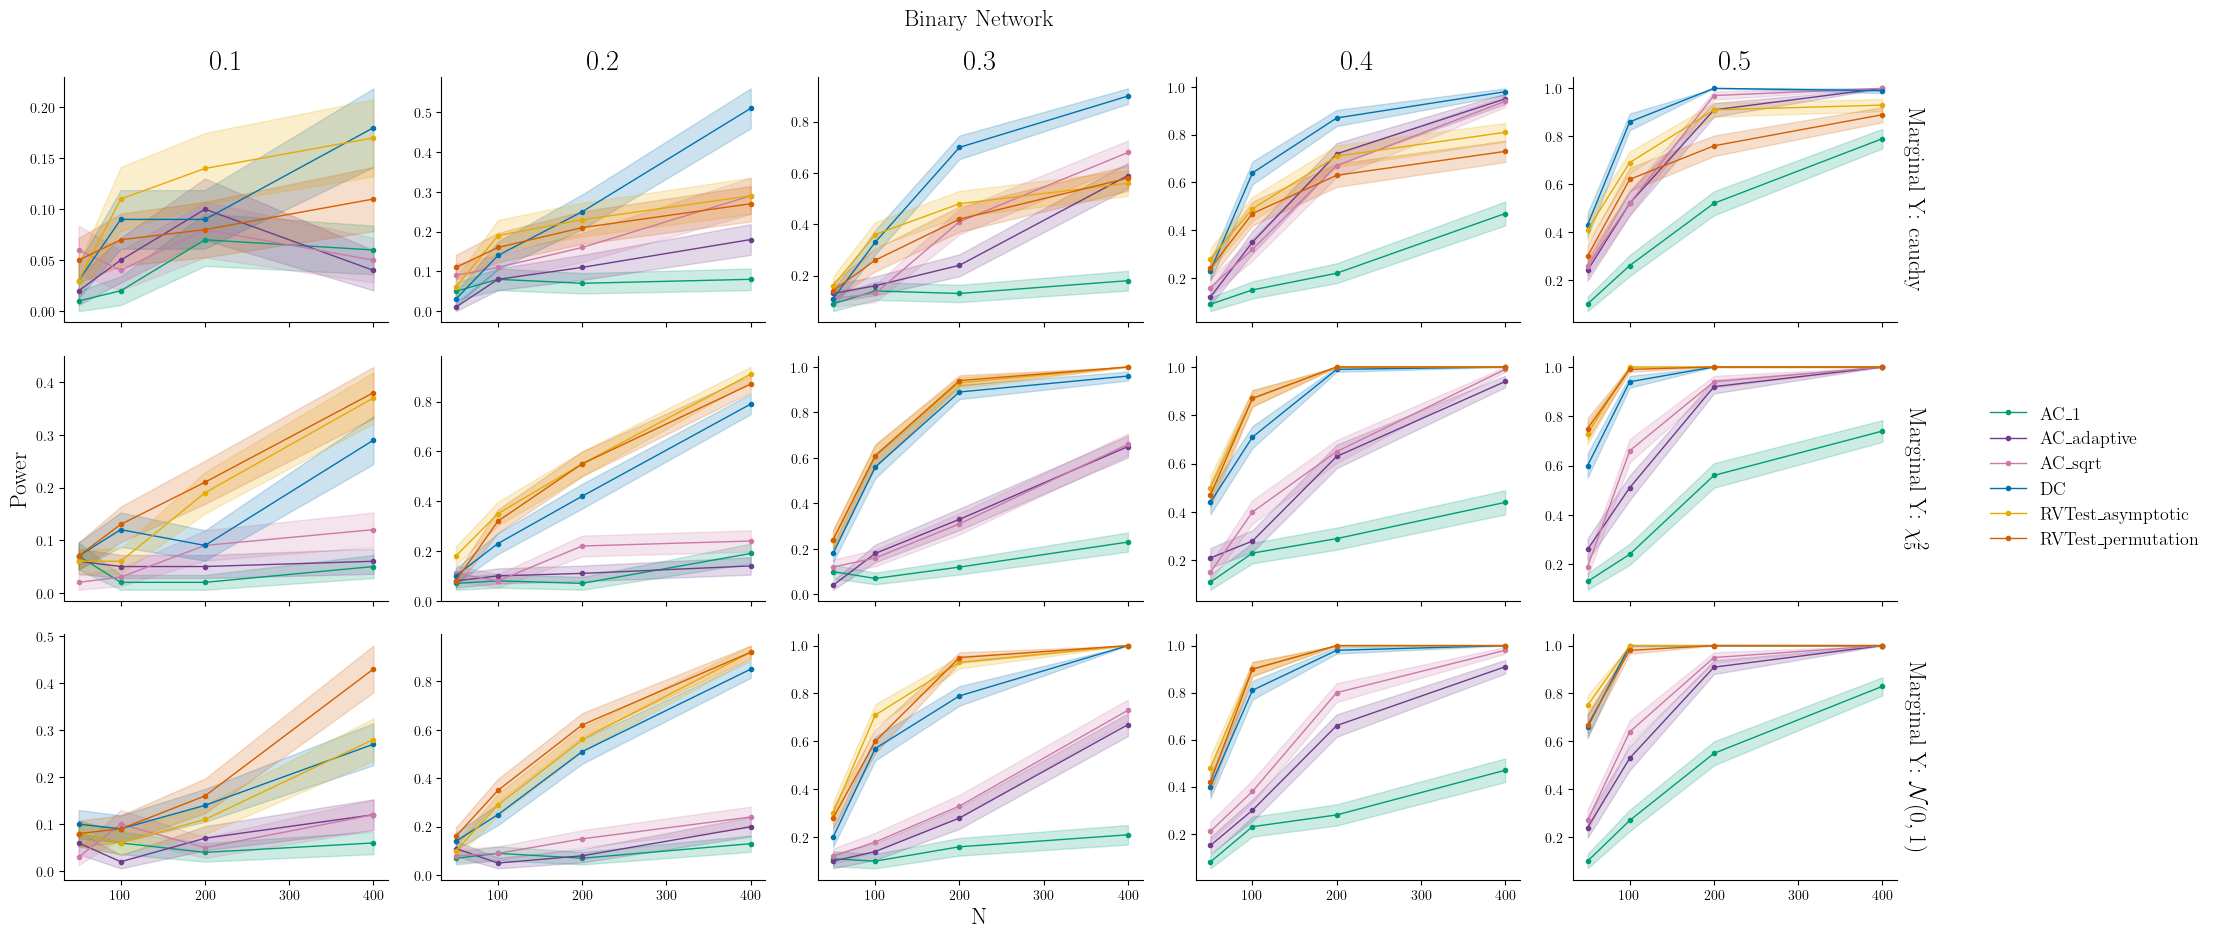

In [34]:
copulas = ['gaussian', '$t_5$', 'clayton', 'mixture']
marginals_z = ['$\\mathcal{N}(0,1)$', '$\\chi^2_{5}$']
marginals_y = ['$\\mathcal{N}(0,1)$', '$\\chi^2_{5}$', 'cauchy']

temp = agg_alt_bernoulli.copy()
temp['copula'] = temp['copula'].replace({'student_t': '$t_5$'})

temp['marginal_z'] = temp['marginal_z'].replace(
    {'chi df=5': '$\\chi^2_{5}$', 
     'gaussian' : '$\\mathcal{N}(0,1)$',
     'unif(-1, 1)' : '$U(-1, 1)$'}
)

temp['marginal_y'] = temp['marginal_y'].replace(
    {'chi df=5': '$\\chi^2_{5}$',
     'gaussian' : '$\\mathcal{N}(0,1)$'}
)

temp = temp.rename(columns={"Rejection_mean": "Power"})

temp = temp[temp['copula'].isin(copulas)]
temp = temp[temp['marginal_z'].isin(marginals_z)]
temp = temp[temp['marginal_y'].isin(marginals_y)]
temp = temp[temp['method'].isin(colors.keys())]
temp = temp[temp['marginal_z']=='$\\mathcal{N}(0,1)$']

# plot_grid(
#     grouped_stats=temp[temp['n']==300],
#     plotting_function=plot_scatter_markers,
#     x_axis="marginal_y",
#     y_axis="Power",
#     factors=["method", "copula", 'marginal_z'],
#     height=2.5,
#     aspect=1.7,
#     colors=colors,
#     markers=marker_map,
#     add_legend=True,
#     title="",
#     show_x_axis_title=False,
#     x_tick_labelsize=15,  # ← overrides xtick.labelsize: 10 from rcParams
#     y_tick_labelsize=15,  # ← same for y (optional)
#     x_tick_rotation=0,
#     x_order=marginals_y,
#     col_order=copulas,
#     marker_size=50
# )

plot_grid(
    grouped_stats=temp,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="Power",
    factors=["method", "rho", "marginal_y"],
    height=3,
    se_bands="Rejection_sem",
    share_x=True,
    share_y=False,
    title="Binary Network",
    colors=colors,
    show_row_titles=True,
    show_col_names=False,
    # col_order=copulas,
)

In [19]:
temp = agg_alt_gaussian.copy()
temp = temp[temp['copula'].isin(copulas)]
temp = temp[temp['marginal_z'].isin(marginals_z)]
temp = temp[temp['marginal_y'].isin(marginals_y)]
temp = temp[temp['method'].isin(colors.keys())]

plot_grid(
    grouped_stats=temp[temp['n']==300],
    plotting_function=plot_scatter_markers,
    x_axis="marginal_y",
    y_axis="Rejection_mean",
    factors=["method", "copula", 'marginal_z'],
    height=3,
    aspect=1.5,
    colors=colors,
    markers=marker_map,
    add_legend=True,
    title="Gaussian Network, n=500",
    show_x_axis_title=False,
    x_tick_labelsize=15,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=15,  # ← same for y (optional)
    x_tick_rotation=0,
    x_order=marginals_y,
    col_order=copulas,
)

plot_grid(
    grouped_stats=temp[temp['marginal_z']=='gaussian'],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="Rejection_mean",
    factors=["method", "copula", "marginal_y"],
    height=3,
    se_bands="Rejection_sem",
    share_x=True,
    share_y=True,
    title="Gaussian Network",
    colors=colors,
    show_row_titles=True,
    show_col_names=False,
    col_order=copulas,
)

ValueError: Number of rows must be a positive integer, not 0

<Figure size 1800x0 with 0 Axes>

In [ ]:
all_sim = [
    "linear",
    "exponential",
    "cubic",
    "step",
    "circle",
    "ellipse",
    "spiral",
    "quadratic",
    "fourth_root",
    "log",
    "w_shaped",
    "two_parabolas",
    "bernoulli",
    "square",
    "diamond",
    "sin_sixteen_pi",
]

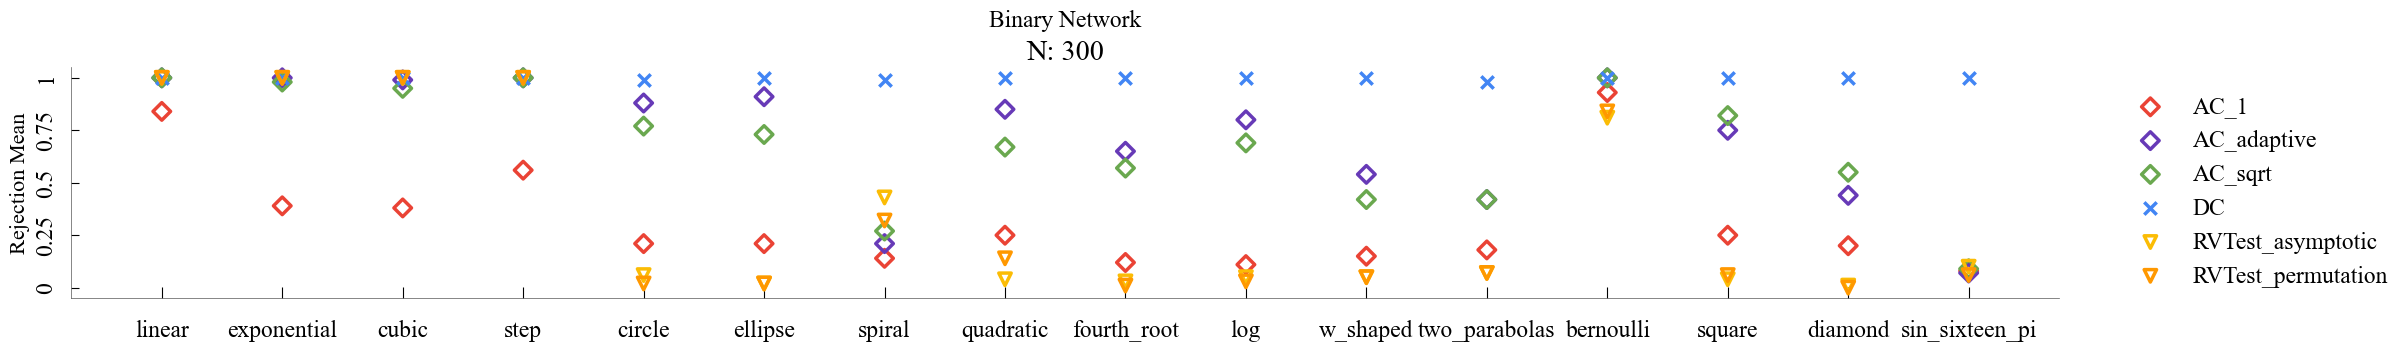

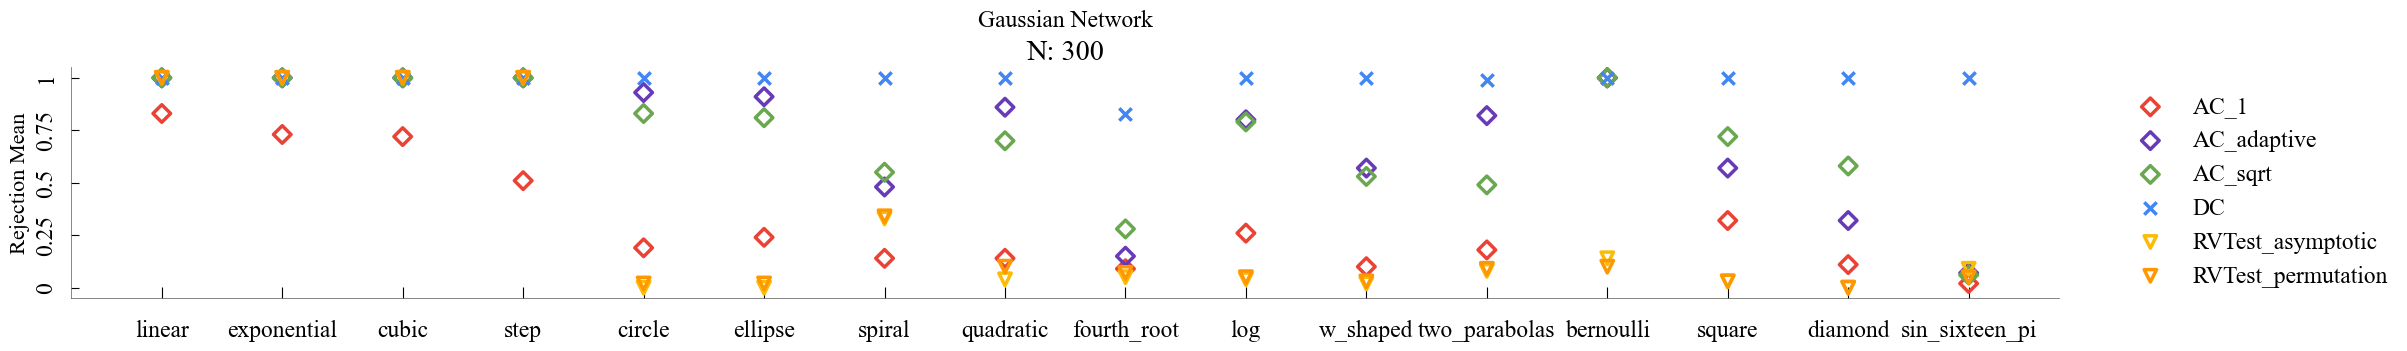

In [ ]:
temp = agg_alt_bernoulli.copy()
temp = temp[temp['latent_sim'].isin(all_sim)]
temp = temp[temp['method'].isin(colors.keys())]

plot_grid(
    grouped_stats=temp[temp["n"] == 300],
    x_axis="latent_sim",
    y_axis="Rejection_mean",
    factors=["method", "n"],
    plotting_function=plot_scatter_markers,
    colors=colors,
    markers=marker_map,
    height=3.5,
    aspect=6,
    add_legend=True,
    x_order=all_sim,
    show_x_axis_title=False,
    x_tick_labelsize=17,
    y_tick_labelsize=17,
    x_tick_rotation=0,
    title="Binary Network",
)

temp = agg_alt_gaussian.copy()
temp = temp[temp['latent_sim'].isin(all_sim)]
temp = temp[temp['method'].isin(colors.keys())]

plot_grid(
    grouped_stats=temp[temp["n"] == 300],
    x_axis="latent_sim",
    y_axis="Rejection_mean",
    factors=["method", "n"],
    plotting_function=plot_scatter_markers,
    colors=colors,
    markers=marker_map,
    height=3.5,
    aspect=6,
    add_legend=True,
    x_order=all_sim,
    show_x_axis_title=False,
    x_tick_labelsize=17,
    y_tick_labelsize=17,
    x_tick_rotation=0,
    title="Gaussian Network",
)

In [ ]:
all_functional_forms = [
    "linear",
    "interaction",
    "pareto",
    "max",
    "abs_max",
    "radial",
    "sine",
    "tanh_product",
]

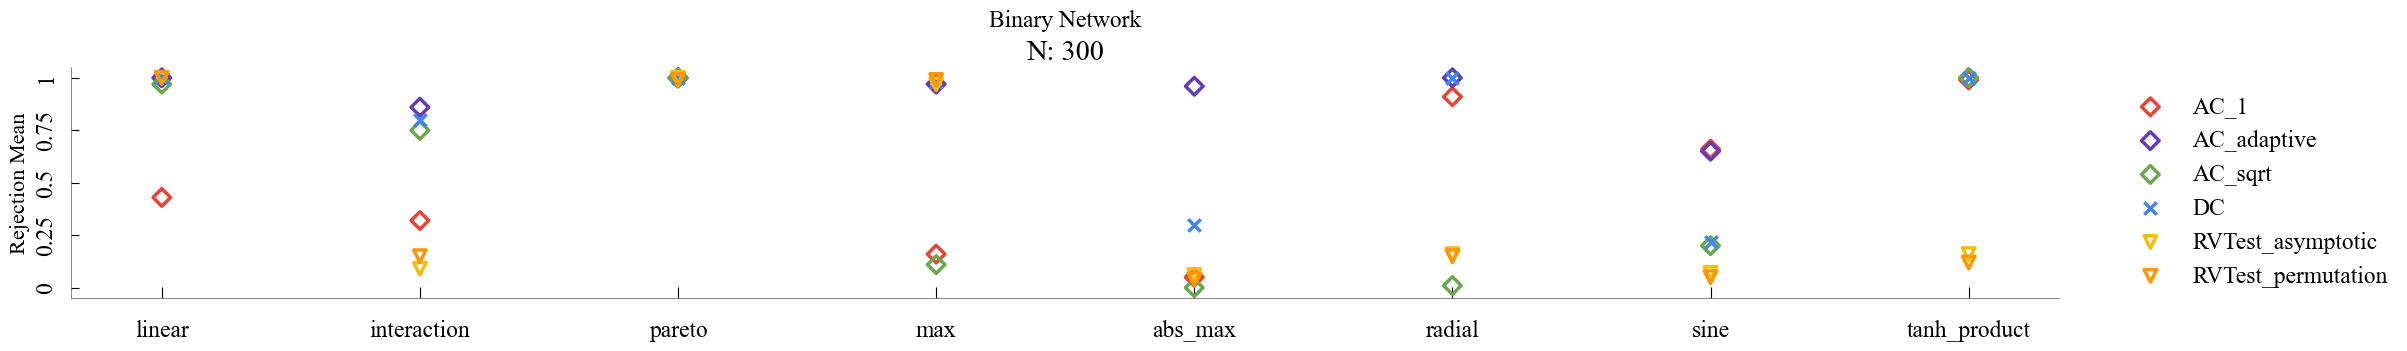

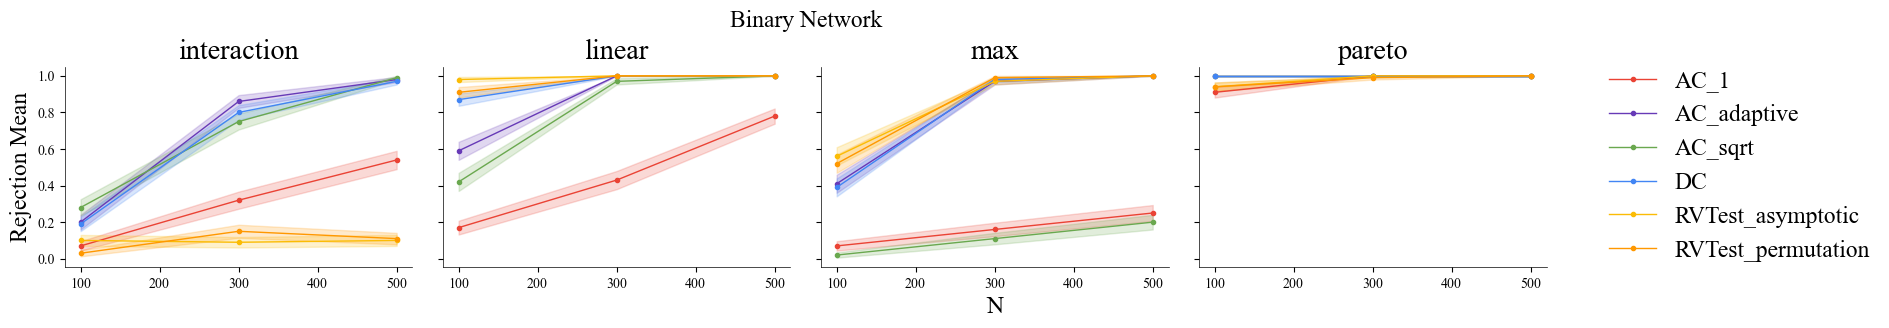

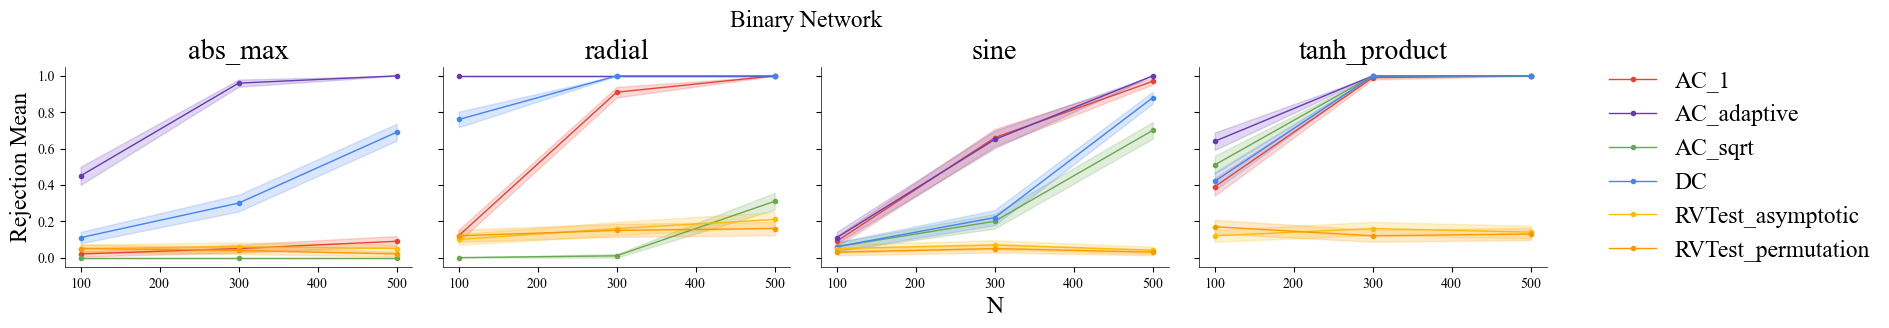

In [ ]:
temp = agg_alt_bernoulli.copy()
temp = temp[temp['functional_form'].isin(all_functional_forms)]
temp = temp[temp['method'].isin(colors.keys())]

plot_grid(
    grouped_stats=temp[temp["n"] == 300],
    x_axis="functional_form",
    y_axis="Rejection_mean",
    factors=["method", "n",],
    plotting_function=plot_scatter_markers,
    colors=colors,
    markers=marker_map,
    height=3.5,
    aspect=6,
    add_legend=True,
    x_order=all_functional_forms,
    show_x_axis_title=False,
    x_tick_labelsize=17,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=17,  # ← same for y (optional)
    x_tick_rotation=0,
    title="Binary Network",
)


plot_grid(
    grouped_stats=temp[temp["functional_form"].isin(all_functional_forms[:4])],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="Rejection_mean",
    factors=["method", "functional_form"],
    height=3,
    se_bands="Rejection_sem",
    share_x=True,
    share_y=True,
    title="Binary Network",
    colors=colors,
    show_row_titles=True,
    show_col_names=False,
)

plot_grid(
    grouped_stats=temp[temp["functional_form"].isin(all_functional_forms[4:])],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="Rejection_mean",
    factors=["method", "functional_form"],
    height=3,
    se_bands="Rejection_sem",
    share_x=True,
    share_y=True,
    title="Binary Network",
    colors=colors,
    show_row_titles=True,
    show_col_names=False,
)

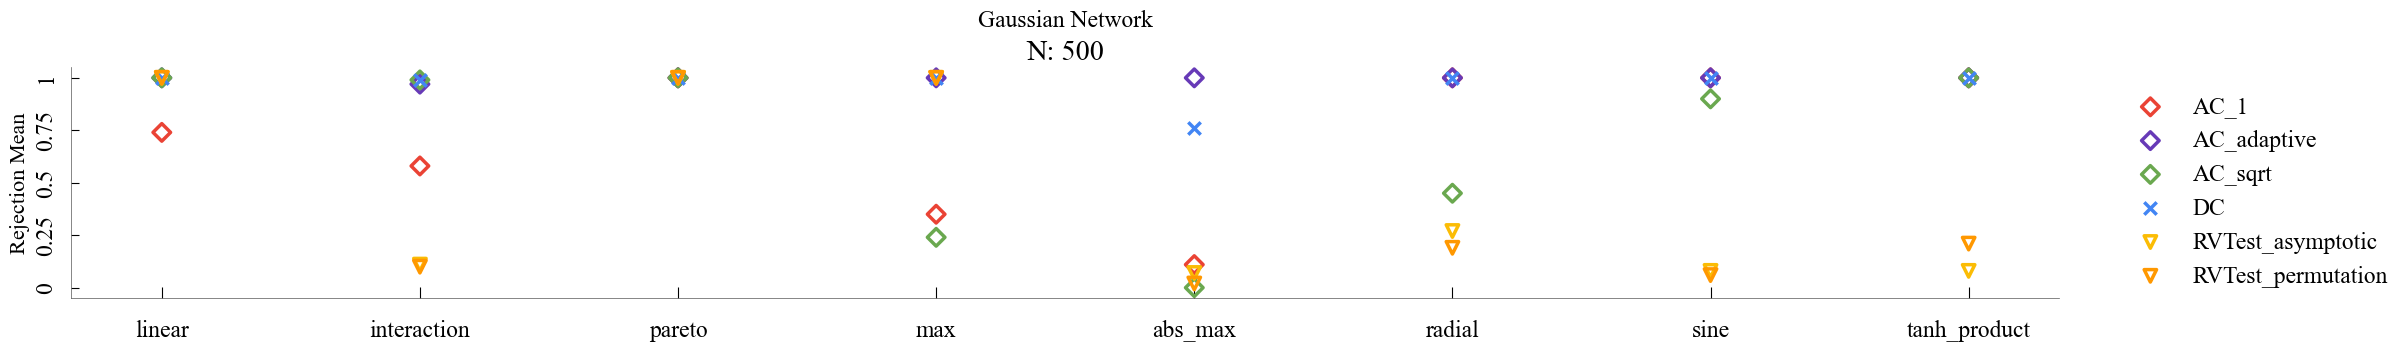

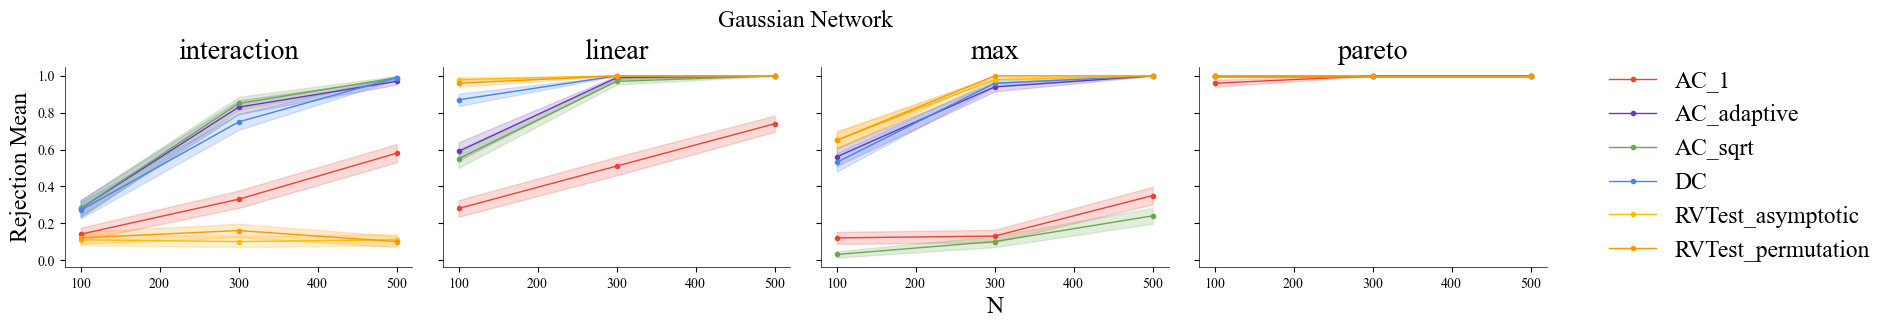

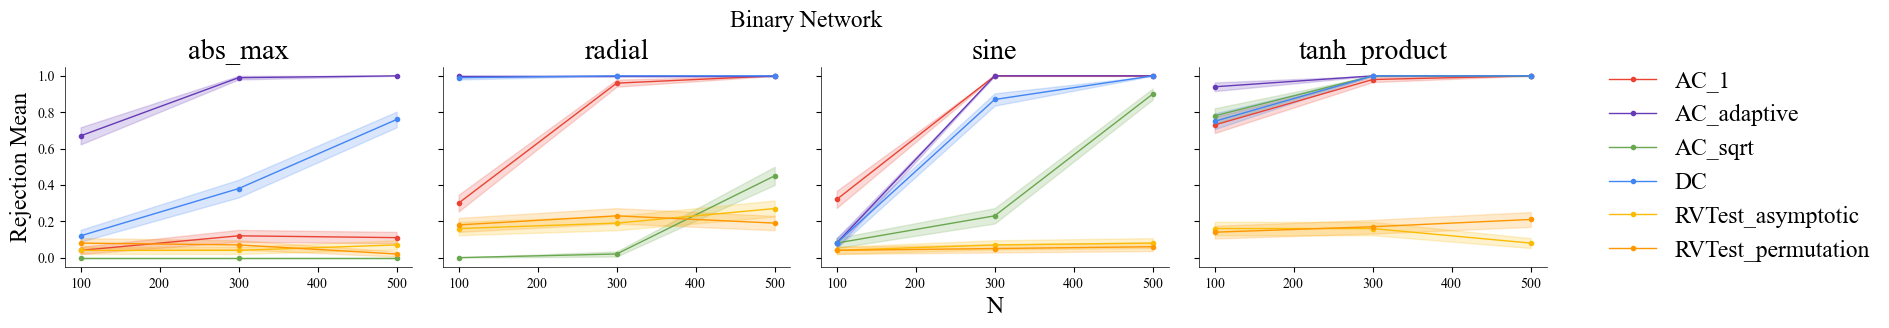

In [ ]:
temp = agg_alt_gaussian.copy()
temp = temp[temp['functional_form'].isin(all_functional_forms)]
temp = temp[temp['method'].isin(colors.keys())]

plot_grid(
    grouped_stats=temp[temp["n"] == 500],
    x_axis="functional_form",
    y_axis="Rejection_mean",
    factors=["method", "n",],
    plotting_function=plot_scatter_markers,
    colors=colors,
    markers=marker_map,
    height=3.5,
    aspect=6,
    add_legend=True,
    x_order=all_functional_forms,
    show_x_axis_title=False,
    x_tick_labelsize=17,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=17,  # ← same for y (optional)
    x_tick_rotation=0,
    title="Gaussian Network",
)


plot_grid(
    grouped_stats=temp[temp["functional_form"].isin(all_functional_forms[:4])],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="Rejection_mean",
    factors=["method", "functional_form"],
    height=3,
    se_bands="Rejection_sem",
    share_x=True,
    share_y=True,
    title="Gaussian Network",
    colors=colors,
    show_row_titles=True,
    show_col_names=False,
)

plot_grid(
    grouped_stats=temp[temp["functional_form"].isin(all_functional_forms[4:])],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="Rejection_mean",
    factors=["method", "functional_form"],
    height=3,
    se_bands="Rejection_sem",
    share_x=True,
    share_y=True,
    title="Binary Network",
    colors=colors,
    show_row_titles=True,
    show_col_names=False,
)

In [ ]:
# all_sbm = ['step', 'softmax']

# temp = agg_alt_bernoulli.copy()
# temp = temp[temp['sbm_covariate_sampling'].isin(all_sbm)]
# temp = temp[temp['method'].isin(colors.keys())]

# plot_grid(
#     grouped_stats=temp[temp["n"] == 500],
#     x_axis="sbm_covariate_sampling",
#     y_axis="Rejection_mean",
#     factors=["method", "x_distribution", 'assortativity'],
#     plotting_function=plot_scatter_markers,
#     colors=colors,
#     markers=marker_map,
#     height=2.5,
#     aspect=1.5,
#     add_legend=True,
#     x_order=all_sbm,
#     show_x_axis_title=False,
#     show_col_names=False,
#     x_tick_labelsize=17,  # ← overrides xtick.labelsize: 10 from rcParams
#     y_tick_labelsize=17,  # ← same for y (optional)
#     x_tick_rotation=0,
#     title="Binary Network",
# )

# plot_grid(
#     grouped_stats=temp[temp['sbm_covariate_sampling'].isin(all_sbm[1:])],
#     plotting_function=plot_with_bands,
#     x_axis="n",
#     y_axis="Rejection_mean",
#     factors=["method", "assortativity", "x_distribution"],
#     height=2.5,
#     se_bands="Rejection_sem",
#     share_x=True,
#     share_y=True,
#     title="Gaussian Network",
#     colors=colors,
#     show_row_titles=True,
#     show_col_names=False,
# )

In [ ]:
# all_sbm = ['step', 'softmax']

# temp = agg_alt_gaussian.copy()
# temp = temp[temp['sbm_covariate_sampling'].isin(all_sbm)]
# temp = temp[temp['method'].isin(colors.keys())]

# plot_grid(
#     grouped_stats=temp[temp["n"] == 500],
#     x_axis="sbm_covariate_sampling",
#     y_axis="Rejection_mean",
#     factors=["method", "x_distribution", 'assortativity'],
#     plotting_function=plot_scatter_markers,
#     colors=colors,
#     markers=marker_map,
#     height=2.5,
#     aspect=1.5,
#     add_legend=True,
#     x_order=all_sbm,
#     show_x_axis_title=False,
#     show_col_names=False,
#     x_tick_labelsize=17,  # ← overrides xtick.labelsize: 10 from rcParams
#     y_tick_labelsize=17,  # ← same for y (optional)
#     x_tick_rotation=0,
#     title="Gaussian Network",
# )

# # plot_grid(
# #     grouped_stats=temp[temp['sbm_covariate_sampling'].isin(all_sbm[:1])],
# #     plotting_function=plot_with_bands,
# #     x_axis="n",
# #     y_axis="Rejection_mean",
# #     factors=["method", "assortativity", "x_distribution"],
# #     height=3,
# #     se_bands="Rejection_sem",
# #     share_x=True,
# #     share_y=True,
# #     title="Gaussian Network",
# #     colors=colors,
# #     show_row_titles=True,
# #     show_col_names=False,
# # )

# plot_grid(
#     grouped_stats=temp[temp['sbm_covariate_sampling'].isin(all_sbm[1:])],
#     plotting_function=plot_with_bands,
#     x_axis="n",
#     y_axis="Rejection_mean",
#     factors=["method", "assortativity", "x_distribution"],
#     height=3,
#     se_bands="Rejection_sem",
#     share_x=True,
#     share_y=True,
#     title="Gaussian Network",
#     colors=colors,
#     show_row_titles=True,
#     show_col_names=False,
# )